# 00 — Fresh Run Initialization

Start here to wipe all pipeline artifacts and run the notebooks cleanly from scratch.

Each notebook in the pipeline writes to a specific data directory. Running this
notebook clears them all so you can re-run 01 → 13 without stale data interfering.

| Directory | Produced by |
|-----------|-------------|
| `01_corpus/` | NB01 — Corpus Collection |
| `02_knowledge/` | NB02–09 — Knowledge extraction + accumulated pairs |
| `03_raw_generated/` | NB10 — Synthetic data generation |
| `04_validated/` | NB11 — Validation |
| `05_dataset/` | NB12 — Dataset assembly |
| `adapters/` | NB04 — Warm-start LoRA adapters |
| `wiki/` | NB08 — Wiki clone |
| `sft_data/` | NB10 — RL fine-tune data |
| `../models/` | NB13 — Fine-tuned model checkpoints |

## Pipeline order

| NB | File | What it does |
|----|------|--------------|
| 00 | `00_init` | Clear all pipeline output (this notebook) |
| 01 | `01_corpus_collection` | Collect ARO source corpus |
| 02 | `02_knowledge_extraction` | Extract structured knowledge |
| 03 | `03_llm_knowledge_extraction` | LLM-assisted extraction |
| 04 | `04_warmstart_finetune` | Warm-start LoRA adapter |
| 05 | `05_actions_training` | Actions reference pairs |
| 06 | `06_repl_execution_training` | Execution-grounded pairs |
| 07 | `07_book_qa_pairs` | Book Q&A pairs |
| 08 | `08_wiki_training` | Wiki Q&A pairs |
| 09 | `09_git_training` | Git history fix/refactor pairs |
| 10 | `10_synthetic_data_generation` | Synthetic data (GRPO-style) |
| 11 | `11_validation` | Filter by `aro check` |
| 12 | `12_dataset_assembly` | Merge + split train/valid/test |
| 13 | `13_finetune` | Full LoRA fine-tune |
| 14 | `14_evaluation` | Evaluate on test set |
| 15 | `15_iterative_loop` | Self-improvement rounds |
| 16 | `16_package` | Quantize + distribute |
| 17 | `17_chat` | Interactive chat loop |

The base model cache is **not** touched — no re-downloading needed.

In [9]:
import sys, importlib, shutil
from pathlib import Path

_cfg_dir = Path('.').resolve()
if str(_cfg_dir) not in sys.path:
    sys.path.insert(0, str(_cfg_dir))
import config; importlib.reload(config); from config import *

# Every directory produced by the pipeline, paired with a description.
# Order matches pipeline stage order so the output reads top-to-bottom.
STAGE_DIRS = [
    (DATA_ROOT / '01_corpus',        'NB01  — Corpus Collection'),
    (DATA_ROOT / '02_knowledge',     'NB02–07b — Knowledge + Accumulated Pairs'),
    (DATA_ROOT / '03_raw_generated', 'NB08  — Synthetic Data Generation'),
    (DATA_ROOT / '04_validated',     'NB09  — Validation'),
    (DATA_ROOT / '05_dataset',       'NB10  — Dataset Assembly'),
    (DATA_ROOT / 'adapters',         'NB04  — Warm-start LoRA Adapters'),
    (DATA_ROOT / 'wiki',             'NB07b — Wiki Clone'),
    (DATA_ROOT / 'sft_data',         'NB08  — RL Fine-tune Data'),
    (SCRIPT_DIR / '../models',       'NB11  — Fine-tuned Model Checkpoints'),
]

print('Directories that will be cleared:\n')
total_files = 0
for d, label in STAGE_DIRS:
    p = Path(d)
    if p.exists():
        n = sum(1 for _ in p.rglob('*') if _.is_file())
        total_files += n
        print(f'  [{label}]')
        print(f'    {p}  ({n} files)')
    else:
        print(f'  [{label}]')
        print(f'    {p}  — not present, will be skipped')

print(f'\nTotal files to remove: {total_files}')
print('\nRun the next cell to confirm and delete.')

Fine-tuned model not found on HuggingFace, using base: mlx-community/Qwen3-Coder-30B-A3B-Instruct-4bit
Directories that will be cleared:

  [NB01  — Corpus Collection]
    /Volumes/Models/data/../data/01_corpus  — not present, will be skipped
  [NB02–07b — Knowledge + Accumulated Pairs]
    /Volumes/Models/data/../data/02_knowledge  (2 files)
  [NB08  — Synthetic Data Generation]
    /Volumes/Models/data/../data/03_raw_generated  (0 files)
  [NB09  — Validation]
    /Volumes/Models/data/../data/04_validated  (0 files)
  [NB10  — Dataset Assembly]
    /Volumes/Models/data/../data/05_dataset  (0 files)
  [NB04  — Warm-start LoRA Adapters]
    /Volumes/Models/data/../data/adapters  (0 files)
  [NB07b — Wiki Clone]
    /Volumes/Models/data/../data/wiki  (0 files)
  [NB08  — RL Fine-tune Data]
    /Volumes/Models/data/../data/sft_data  (0 files)
  [NB11  — Fine-tuned Model Checkpoints]
    /Users/kris/Projects/ARO-App/Train/script/../models  (0 files)

Total files to remove: 2

Run the next

## Confirm and Delete

**This is irreversible.** Review the file counts above, then run the cell below.

In [10]:
cleared, skipped = [], []
_file_counts = {}   # label → files removed (for graph)

for d, label in STAGE_DIRS:
    p = Path(d)
    if p.exists():
        n = sum(1 for _ in p.rglob('*') if _.is_file())
        shutil.rmtree(p)
        p.mkdir(parents=True, exist_ok=True)
        cleared.append(label)
        _file_counts[label] = n
    else:
        skipped.append(label)
        _file_counts[label] = 0

# Recreate the ADAPTER_DIR that config.py mkdir's on import
ADAPTER_DIR.mkdir(parents=True, exist_ok=True)

print(f'\nDone.  {len(cleared)} cleared,  {len(skipped)} skipped.')
print('\nNext: run notebooks 01 → 11 in order to regenerate all data.')


Done.  8 cleared,  1 skipped.

Next: run notebooks 01 → 11 in order to regenerate all data.


## Fix Training Data

Generates three JSONL files from the FIXTRAIN.md issue catalogue and seeds
`knowledge_pairs.jsonl` with them so every pipeline run trains on the corrections.

| File | Content | Pairs |
|------|---------|-------|
| `fix_wrong_explanation.jsonl` | wrong code → why it is wrong | 44 |
| `fix_wrong_fix.jsonl`         | wrong code → corrected code  | 44 |
| `fix_explanation_fix.jsonl`   | explanation → corrected code | 44 |

These are appended to `knowledge_pairs.jsonl` immediately after the directory is cleared,
so subsequent notebooks (02–07b) add their pairs on top.

In [11]:
import importlib, json
import fix_training_data; importlib.reload(fix_training_data)

# Generate (or regenerate) the three fix JSONL files in the script directory
p1, p2, p3 = fix_training_data.generate(out_dir=SCRIPT_DIR)

# Seed knowledge_pairs.jsonl with all three lists
PAIRS_FILE.parent.mkdir(parents=True, exist_ok=True)

total_seeded = 0
with PAIRS_FILE.open('a') as out:
    for path in (p1, p2, p3):
        lines = [l for l in path.read_text().splitlines() if l.strip()]
        for line in lines:
            out.write(line + '\n')
        total_seeded += len(lines)

print(f'\nSeeded {total_seeded} fix pairs into {PAIRS_FILE}')
print(f'  {p1.name:<35} {sum(1 for _ in p1.read_text().splitlines() if _.strip())} pairs')
print(f'  {p2.name:<35} {sum(1 for _ in p2.read_text().splitlines() if _.strip())} pairs')
print(f'  {p3.name:<35} {sum(1 for _ in p3.read_text().splitlines() if _.strip())} pairs')

fix_wrong_explanation.jsonl  — 47 pairs → /Users/kris/Projects/ARO-App/Train/script/fix_wrong_explanation.jsonl
fix_wrong_fix.jsonl          — 47 pairs → /Users/kris/Projects/ARO-App/Train/script/fix_wrong_fix.jsonl
fix_explanation_fix.jsonl    — 47 pairs → /Users/kris/Projects/ARO-App/Train/script/fix_explanation_fix.jsonl

Seeded 141 fix pairs into /Volumes/Models/data/../data/02_knowledge/knowledge_pairs.jsonl
  fix_wrong_explanation.jsonl         47 pairs
  fix_wrong_fix.jsonl                 47 pairs
  fix_explanation_fix.jsonl           47 pairs


## Git History Training Data

Mines fix/refactor commits from real ARO application repos and the ARO example
corpus at runtime, producing explanation + fix training pairs.\n\n
| File | Source |\n|------|--------|\n| `git_applications_pairs.jsonl` | `/Users/kris/Projects/ARO-Application/*` |\n| `git_examples_pairs.jsonl` | ARO repo `Examples/`, `Book/`, `Proposals/` |

In [12]:
import importlib, subprocess, re, json as _json
from pathlib import Path as _Path

# ── inline the git mining logic so 00_init is self-contained ──────────────

_ARO_APPLICATION_ROOT = _Path('/Users/kris/Projects/ARO-Application')
_FIX_PATTERN = re.compile(
    r'\b(fix|refactor|correct|simplif|improv|replac|rewrite|clean|migrat|updat|use typed|eliminate|remove duplication)\b',
    re.IGNORECASE,
)
_MIN_HUNK = 1
_SYSTEM = (
    "You are an expert ARO (Action Result Object) programmer. "
    "ARO is a DSL where every statement is: Verb the <Result> preposition [the] <Object>. "
    "Feature sets follow (Name: Business Activity) { statements }. "
    "Variables are immutable. String concatenation uses ++. "
    "Event publishing uses Emit a <Name: event> with <data>."
)


def _git(*args, cwd):
    r = subprocess.run(['git'] + list(args), cwd=str(cwd), capture_output=True, text=True)
    return r.stdout if r.returncode == 0 else ''


def _get_commits(repo, glob):
    log = _git('log', '--format=%H\t%s\t%b<END_BODY>', '--diff-filter=M', '--', glob, cwd=repo)
    commits = []
    for block in log.split('<END_BODY>'):
        block = block.strip()
        if not block:
            continue
        first, *rest = block.splitlines()
        parts = first.split('\t', 2)
        if len(parts) < 2:
            continue
        sha, subject, body = parts[0], parts[1], '\n'.join(rest).strip()
        if not _FIX_PATTERN.search(subject + ' ' + body):
            continue
        diff = _git('show', sha, '--no-color', '--unified=3', '--', glob, cwd=repo)
        if diff:
            commits.append({'sha': sha[:10], 'subject': subject, 'body': body,
                            'diff_text': diff, 'repo': repo.name})
    return commits


def _parse_hunks(diff_text):
    hunks, current_file, old, new = [], None, [], []

    def _flush():
        o = [l for l in old if l.strip()]
        n = [l for l in new if l.strip()]
        if len(o) >= _MIN_HUNK and len(n) >= _MIN_HUNK:
            hunks.append({'file': current_file, 'old_lines': o, 'new_lines': n})
        old.clear(); new.clear()

    in_diff = False
    for line in diff_text.splitlines():
        if line.startswith('diff --git'):
            _flush(); in_diff = True
            m = re.search(r'b/(.+)$', line)
            current_file = m.group(1) if m else None
        elif not in_diff:
            continue
        elif line.startswith('@@'):
            _flush()
        elif line.startswith(('---', '+++')):
            pass
        elif line.startswith('-'):
            old.append(line[1:])
        elif line.startswith('+'):
            new.append(line[1:])
    _flush()
    return hunks


def _commit_to_pairs(c):
    expl_parts = [c['subject']]
    body_lines = [l for l in c['body'].splitlines()
                  if l.strip() and not re.match(r'^(Co-authored|Signed-off)', l, re.I)]
    if body_lines:
        expl_parts.append('\n'.join(body_lines))
    explanation = '\n\n'.join(expl_parts)
    pairs = []
    for h in _parse_hunks(c['diff_text']):
        old_code = '\n'.join(h['old_lines'])
        new_code = '\n'.join(h['new_lines'])
        src = f"{c['repo']}/{h['file'] or 'main.aro'}@{c['sha']}"
        pairs.append({
            'messages': [
                {'role': 'system', 'content': _SYSTEM},
                {'role': 'user',   'content': f'Why was this ARO code changed?\n\n```aro\n{old_code}\n```'},
                {'role': 'assistant', 'content': explanation},
            ], 'task_type': 'debugging', 'source': src,
        })
        pairs.append({
            'messages': [
                {'role': 'system', 'content': _SYSTEM},
                {'role': 'user',   'content': f'{explanation}\n\nFix this ARO code accordingly:\n\n```aro\n{old_code}\n```'},
                {'role': 'assistant', 'content': f'```aro\n{new_code}\n```'},
            ], 'task_type': 'debugging', 'source': src,
        })
    return pairs


# ── mine applications ────────────────────────────────────────────────────
app_pairs = []
for _repo in sorted([d for d in _ARO_APPLICATION_ROOT.iterdir()
                     if d.is_dir() and (d / '.git').exists()]):
    _commits = _get_commits(_repo, '*.aro')
    _n = sum(len(_commit_to_pairs(c)) for c in _commits)
    app_pairs.extend(p for c in _commits for p in _commit_to_pairs(c))
    print(f'  {_repo.name:<25} {len(_commits):>3} commits → {_n:>4} pairs')

_out_apps = SCRIPT_DIR / 'git_applications_pairs.jsonl'
with _out_apps.open('w') as _f:
    for _p in app_pairs: _f.write(_json.dumps(_p) + '\n')

# ── mine ARO repo ────────────────────────────────────────────────────────
aro_pairs = []
for _label, _glob in [('Examples', 'Examples/**/*.aro'),
                       ('Book',     'Book/**/*.md'),
                       ('Proposals','Proposals/*.md')]:
    _commits = _get_commits(ARO_ROOT, _glob)
    for _c in _commits: _c['repo'] = f'aro/{_label}'
    _n = sum(len(_commit_to_pairs(c)) for c in _commits)
    aro_pairs.extend(p for c in _commits for p in _commit_to_pairs(c))
    print(f'  aro/{_label:<20} {len(_commits):>3} commits → {_n:>4} pairs')

_out_aro = SCRIPT_DIR / 'git_examples_pairs.jsonl'
with _out_aro.open('w') as _f:
    for _p in aro_pairs: _f.write(_json.dumps(_p) + '\n')

# ── append to PAIRS_FILE ─────────────────────────────────────────────────
PAIRS_FILE.parent.mkdir(parents=True, exist_ok=True)
_total = 0
with PAIRS_FILE.open('a') as _out:
    for _path in (_out_apps, _out_aro):
        _lines = [l for l in _path.read_text().splitlines() if l.strip()]
        for _line in _lines: _out.write(_line + '\n')
        _total += len(_lines)

print(f'\nGit pairs seeded: {_total}  ({len(app_pairs)} apps + {len(aro_pairs)} aro repo)')

  Crawler                     1 commits →    6 pairs
  FediTerm                    0 commits →    0 pairs
  StatusPost                  0 commits →    0 pairs
  Sumup                       3 commits →   18 pairs
  SystemLoadMonitor           0 commits →    0 pairs
  mm                          2 commits →    6 pairs
  mostrecentfile              3 commits →   12 pairs
  rulpz                       1 commits →   20 pairs
  sf                          3 commits →    8 pairs
  aro/Examples              58 commits →  446 pairs
  aro/Book                  39 commits → 1614 pairs
  aro/Proposals             25 commits →  262 pairs

Git pairs seeded: 2392  (70 apps + 2322 aro repo)


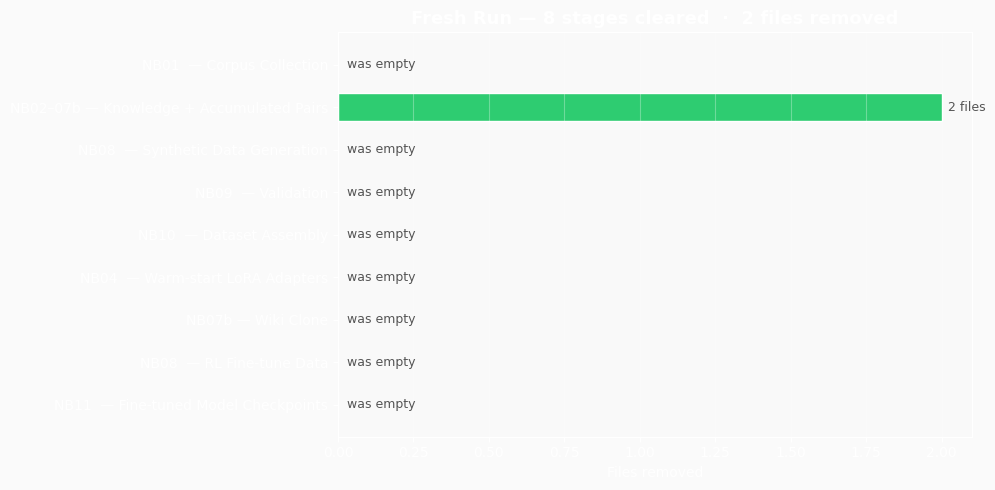

Saved: run/2026-03-25/00_init.png


In [13]:
from pathlib import Path
import matplotlib.pyplot as plt
from datetime import date as _date

_run_dir = Path('.') / 'run' / _date.today().isoformat()
_run_dir.mkdir(parents=True, exist_ok=True)
_out = _run_dir / '00_init.png'

_labels  = [label for _, label in STAGE_DIRS]
_counts  = [_file_counts.get(label, 0) for label in _labels]
_colors  = ['#2ecc71' if label in cleared else '#bdc3c7' for label in _labels]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(_labels, _counts, color=_colors, edgecolor='white', height=0.65)
ax.set_xlabel('Files removed')
ax.set_title(
    f'Fresh Run — {len(cleared)} stages cleared  ·  {sum(_counts):,} files removed',
    fontsize=13, fontweight='bold'
)
for bar, n, label in zip(bars, _counts, _labels):
    tag  = f'{n:,} files' if n else 'was empty'
    xpos = max(n + max(_counts) * 0.01, max(_counts) * 0.015)
    ax.text(xpos, bar.get_y() + bar.get_height() / 2,
            tag, va='center', fontsize=9, color='#555')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)
ax.set_facecolor('#f9f9f9')
fig.patch.set_facecolor('#fafafa')
fig.tight_layout()
fig.savefig(_out, dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)
print(f'Saved: {_out}')